# Imports

In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
#base
import pandas as pd
import numpy as np
# visual
import matplotlib.pyplot as plt
import seaborn as sns
#path
from pathlib import Path
#pipeline
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
# models
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from catboost import CatBoostRegressor
import lightgbm as lgb
from xgboost import XGBRegressor
# metrics
from sklearn.metrics import root_mean_squared_error
#mlflow
import mlflow
import mlflow.sklearn
mlflow.set_tracking_uri("file:///C:/mlflow_runs")
mlflow.set_experiment("house-prices")

<Experiment: artifact_location='file:///C:/mlflow_runs/229563118780063873', creation_time=1781280435250, experiment_id='229563118780063873', last_update_time=1781280435250, lifecycle_stage='active', name='house-prices', tags={}, trace_location=None, workspace='default'>

## Settings

In [15]:
# Path
BASE_DIR = Path.cwd().parent
DATA_DIR   = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SRC_DIR = BASE_DIR / "src"

TRAIN_PATH = DATA_DIR / "raw" / "train.csv"

RANDOM_SEED = 42

#system
import sys
sys.path.append(str(SRC_DIR))

In [16]:
#pipeline
from preproc import HousePreprocessor, optimize_dtypes
from features import FeatureEngineer, add_log_target
from pipeline import build_pipeline
from visual import visualise_mistakes
from modeling import model_train
from modeling import run_stacking
from optuna_tun import run_optuna

In [17]:
# visual
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 12
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False 
plt.rcParams["axes.spines.right"] = False

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.2)
sns.set_context("notebook")

COLORS = {
    'positive': '#2ecc71',
    'negative': '#e74c3c',
    'neutral': '#3498db',
    'highlight': '#f39c12',
    'secondary': '#9b59b6',
}

# Data Load

In [18]:
assert TRAIN_PATH.exists(), f'File not founded: {TRAIN_PATH}'
df = pd.read_csv(TRAIN_PATH)

In [19]:
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [20]:
X_test = pd.read_csv(f'{DATA_DIR}/raw/test.csv')
print(X_test.shape)
X_test.head()

(1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [21]:
test_ids = X_test['Id']
X_test.drop(columns=['Id'])

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


# Models

## Baseline (Linear Regression)

In [39]:
lasso = Lasso(random_state=RANDOM_SEED, alpha=0.001)
ridge = Ridge(random_state=RANDOM_SEED, alpha=1.0)
elasticnet = ElasticNet(random_state=RANDOM_SEED,  alpha=0.001, l1_ratio=0.5)

## Base Pipeline

In [22]:
df_prepared = add_log_target(df)

In [23]:
X_train = df_prepared.drop(columns=['Id', 'SalePrice'])
y_train = df_prepared['SalePrice'] 

In [42]:
models = [
    lasso,
    ridge,
    elasticnet,
]

2026/06/13 05:09:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 05:09:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso RMSE: 0.1290


2026/06/13 05:09:56 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmposkcnv8q\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


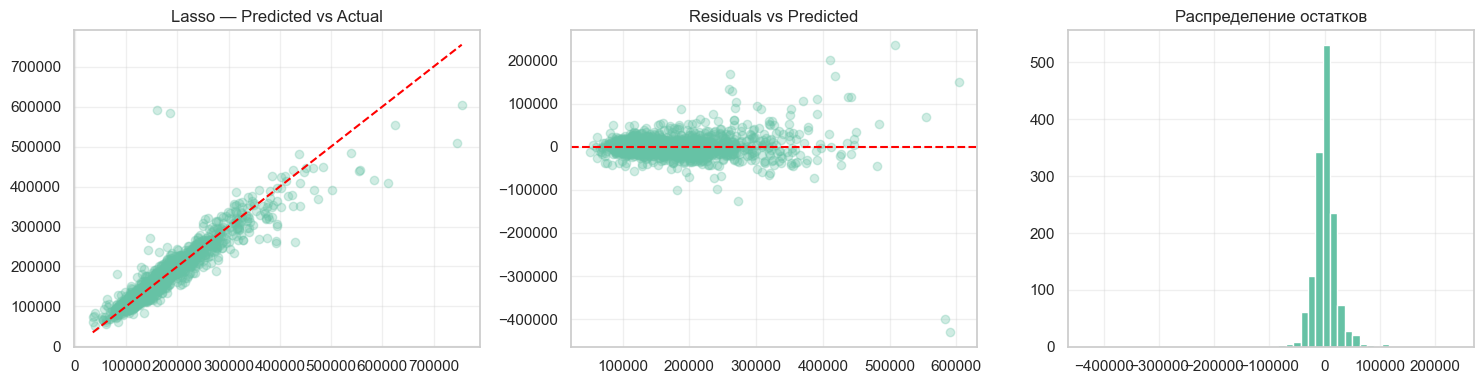

2026/06/13 05:09:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 05:09:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge RMSE: 0.1255


2026/06/13 05:10:01 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmpogf8dpqd\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


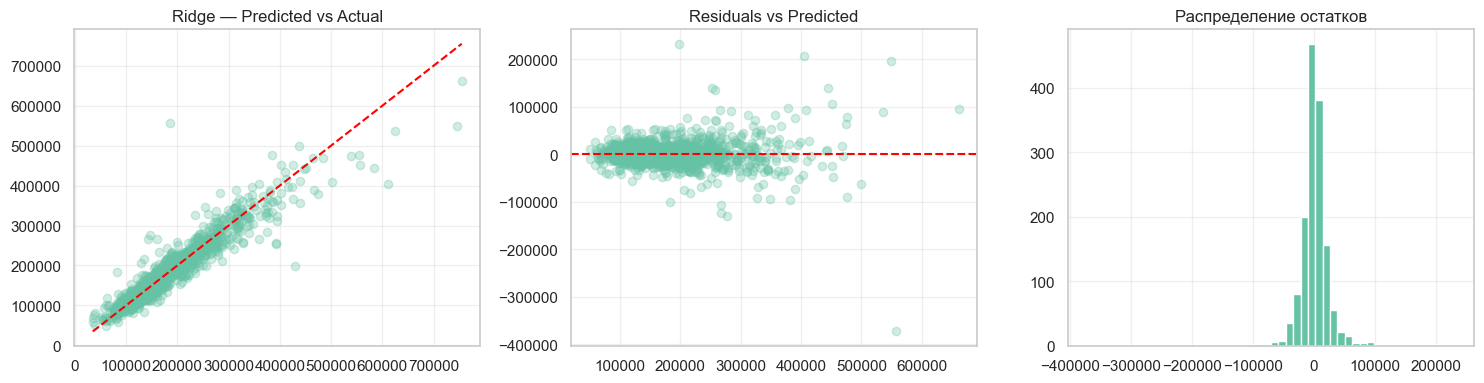

C:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.909e-02, tolerance: 2.123e-02
  model = cd_fast.enet_coordinate_descent(
2026/06/13 05:10:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 05:10:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


ElasticNet RMSE: 0.1270


2026/06/13 05:10:08 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmpa4vkymp9\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


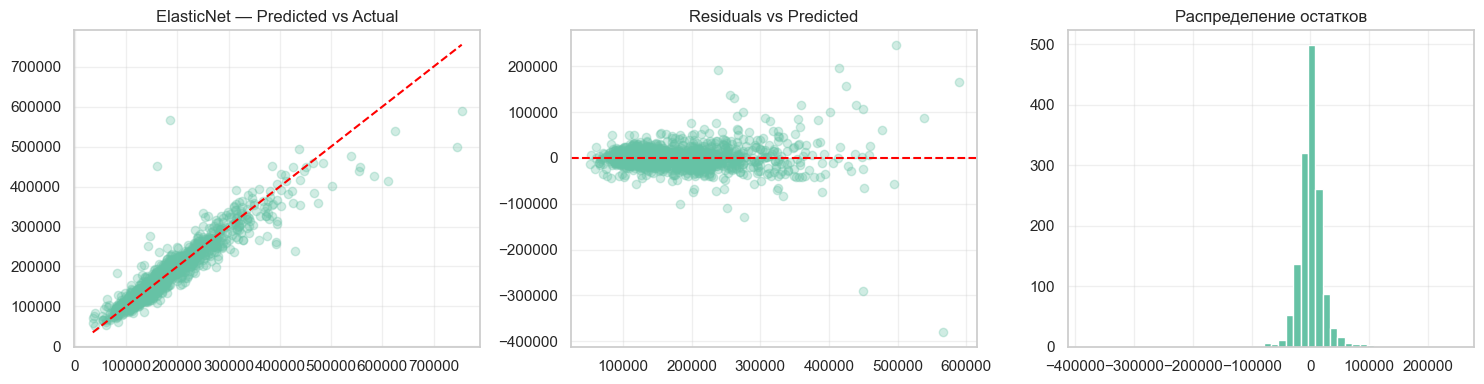

In [43]:
for model in models:
    model, pipe, y_pred, residuals = model_train(model=model,
                                              X_train=X_train,
                                              y_train=y_train,
                                              notes="baseline с изменением альфа",
                                              feature_engineering="v9 = TE + Base + Bool + Multiply + NoLinear Quality",
                                              preprocessing="fillna + clip",
                                              cv_folds=10
                                             )
    
    visualise_mistakes(model, y_train, y_pred, residuals)

## CatBoost, LightGBM, XGboost

In [44]:
catboost = CatBoostRegressor(verbose=0)
lightgbm = lgb.LGBMRegressor(verbose=-1)
xgboost = XGBRegressor(verbosity=0)
models = [
    lightgbm,
    xgboost,
    catboost,
]

In [45]:
df_prepared = add_log_target(df)
X_train = df_prepared.drop(columns=['Id', 'SalePrice'])
y_train = df_prepared['SalePrice']

LGBMRegressor RMSE: 0.1300


2026/06/13 05:10:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 05:10:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/13 05:10:41 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmpq71yrboq\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


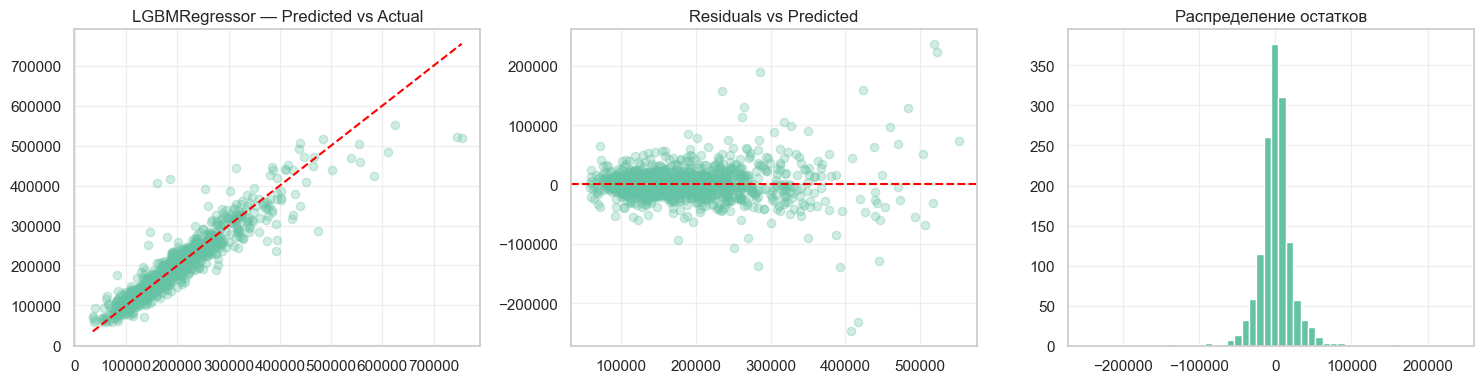

XGBRegressor RMSE: 0.1387


2026/06/13 05:10:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 05:10:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/13 05:10:51 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmpmimxt6uj\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


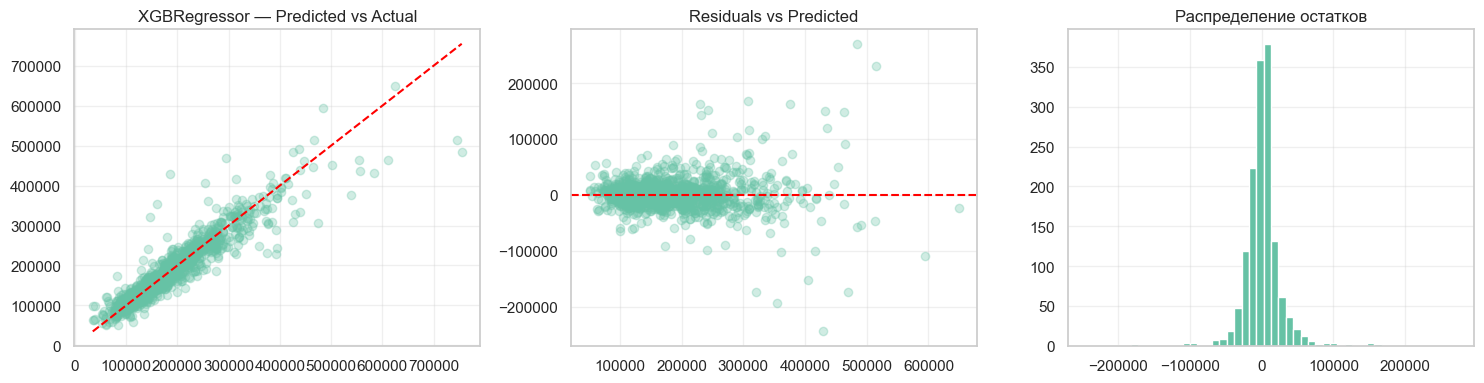

CatBoostRegressor RMSE: 0.1176


2026/06/13 05:11:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 05:11:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/13 05:12:04 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmpo1jpwcxp\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


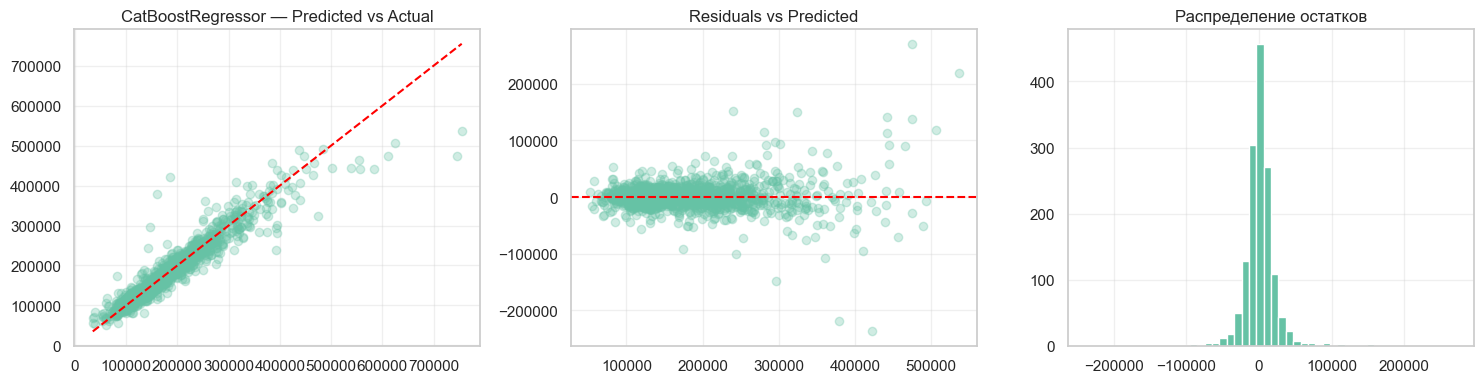

In [46]:
for model in models:
    model, pipe, y_pred, residuals = model_train(model=model,
                                              X_train=X_train,
                                              y_train=y_train,
                                              notes="baseline no tunning",
                                              feature_engineering="v9 = TE + Base + Bool + Multiply + NoLinear Quality",
                                              preprocessing="fillna + clip",
                                              cv_folds=10
                                             )
    
    visualise_mistakes(model, y_train, y_pred, residuals)

## Ridge optuna tunning

In [64]:
study_ridge = run_optuna(Ridge, X_train, y_train, n_trials=50)

[I 2026-06-13 05:39:35,233] A new study created in memory with name: no-name-46fbd6bf-41e9-4b43-9136-7f77bcf60f18


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-13 05:39:36,867] Trial 0 finished with value: 0.1251399660383937 and parameters: {'alpha': 1.431210531047697}. Best is trial 0 with value: 0.1251399660383937.
[I 2026-06-13 05:39:38,530] Trial 1 finished with value: 0.12651688945733208 and parameters: {'alpha': 0.004104001052732293}. Best is trial 0 with value: 0.1251399660383937.
[I 2026-06-13 05:39:40,212] Trial 2 finished with value: 0.12573955120400973 and parameters: {'alpha': 0.16522514378555359}. Best is trial 0 with value: 0.1251399660383937.
[I 2026-06-13 05:39:41,874] Trial 3 finished with value: 0.12909731393001972 and parameters: {'alpha': 20.64771415491006}. Best is trial 0 with value: 0.1251399660383937.
[I 2026-06-13 05:39:43,527] Trial 4 finished with value: 0.12617959207298102 and parameters: {'alpha': 5.488248962853449}. Best is trial 0 with value: 0.1251399660383937.
[I 2026-06-13 05:39:45,200] Trial 5 finished with value: 0.13135492699926726 and parameters: {'alpha': 40.99342244218901}. Best is trial 0 wi

In [24]:
ridge_best_pararms = {'alpha': 0.6531771025930252}
# ridge_best_pararms = study_ridge.best_params

2026/06/13 05:54:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 05:54:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge RMSE: 0.1253


2026/06/13 05:54:56 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmpdw3_ff7v\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


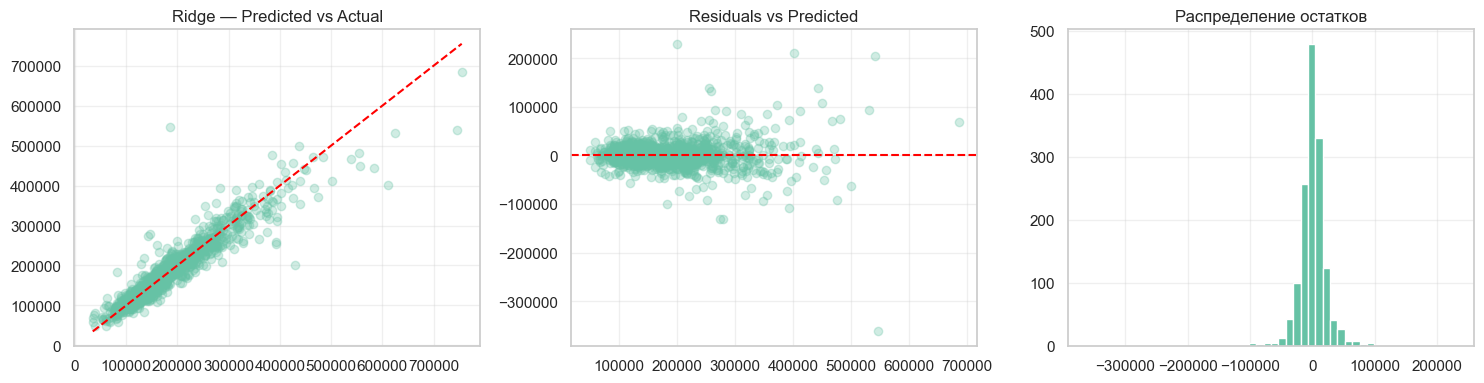

In [72]:
ridge = Ridge(**ridge_best_pararms)
model, pipe, y_pred, residuals = model_train(model=ridge,
                                              X_train=X_train,
                                              y_train=y_train,
                                              notes="ridge after optuna",
                                              feature_engineering="v9 = TE + Base + Bool + Multiply + NoLinear Quality",
                                              preprocessing="fillna + clip",
                                              cv_folds=10
                                             )
    
visualise_mistakes(model, y_train, y_pred, residuals)

## ElasticNet optuna tunning

In [73]:
study_elasticnet = run_optuna(ElasticNet, X_train, y_train, n_trials=50)

[I 2026-06-13 05:56:02,625] A new study created in memory with name: no-name-91e0d04f-1def-4675-b14c-fde9cdfef71d


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-13 05:56:04,429] Trial 0 finished with value: 0.14269895916197334 and parameters: {'alpha': 0.023623073162138193, 'l1_ratio': 0.6921867853669534}. Best is trial 0 with value: 0.14269895916197334.
[I 2026-06-13 05:56:06,145] Trial 1 finished with value: 0.20543266261964221 and parameters: {'alpha': 0.22393313832385872, 'l1_ratio': 0.4716100039777177}. Best is trial 0 with value: 0.14269895916197334.
[I 2026-06-13 05:56:07,836] Trial 2 finished with value: 0.3427516318188415 and parameters: {'alpha': 3.0819800153516197, 'l1_ratio': 0.08167983428976766}. Best is trial 0 with value: 0.14269895916197334.
[I 2026-06-13 05:56:09,587] Trial 3 finished with value: 0.14170129517570765 and parameters: {'alpha': 0.015556368832089778, 'l1_ratio': 0.9785054047586428}. Best is trial 3 with value: 0.14170129517570765.
[I 2026-06-13 05:56:11,331] Trial 4 finished with value: 0.223134877637027 and parameters: {'alpha': 0.1358507698268745, 'l1_ratio': 0.9688372551783047}. Best is trial 3 with 

C:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.773e-01, tolerance: 2.042e-02
  model = cd_fast.enet_coordinate_descent(
C:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.705e-02, tolerance: 2.068e-02
  model = cd_fast.enet_coordinate_descent(
C:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.250e-02, tolerance: 2.016e-02
  model = cd_fast.enet_coo

[I 2026-06-13 05:56:26,011] Trial 8 finished with value: 0.1253373480266165 and parameters: {'alpha': 0.00010808752139060182, 'l1_ratio': 0.2721477628373238}. Best is trial 8 with value: 0.1253373480266165.
[I 2026-06-13 05:56:27,836] Trial 9 finished with value: 0.13666564223257952 and parameters: {'alpha': 0.017184427829307177, 'l1_ratio': 0.40940257423956405}. Best is trial 8 with value: 0.1253373480266165.


...

[I 2026-06-13 05:56:39,128] Trial 10 finished with value: 0.12581742160383988 and parameters: {'alpha': 0.00016903637689767064, 'l1_ratio': 0.06235311011906475}. Best is trial 8 with value: 0.1253373480266165.


C:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.815e+00, tolerance: 2.042e-02
  model = cd_fast.enet_coordinate_descent(
C:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.968e+00, tolerance: 2.067e-02
  model = cd_fast.enet_coordinate_descent(
C:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.401e+00, tolerance: 2.131e-02
  model = cd_fast.enet_coo

[I 2026-06-13 05:56:50,524] Trial 11 finished with value: 0.1261001693258966 and parameters: {'alpha': 0.00014529838217414135, 'l1_ratio': 0.052465847734699866}. Best is trial 8 with value: 0.1253373480266165.


C:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.444e-01, tolerance: 2.042e-02
  model = cd_fast.enet_coordinate_descent(
C:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.783e-02, tolerance: 2.067e-02
  model = cd_fast.enet_coordinate_descent(
C:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.638e-02, tolerance: 2.131e-02
  model = cd_fast.enet_coo

[I 2026-06-13 05:57:00,958] Trial 12 finished with value: 0.12564374850191293 and parameters: {'alpha': 0.00011189328142539607, 'l1_ratio': 0.23719901190902046}. Best is trial 8 with value: 0.1253373480266165.
[I 2026-06-13 05:57:03,518] Trial 13 finished with value: 0.1262814713737807 and parameters: {'alpha': 0.0014526851284535334, 'l1_ratio': 0.2486099438189733}. Best is trial 8 with value: 0.1253373480266165.
[I 2026-06-13 05:57:06,435] Trial 14 finished with value: 0.1254074906473145 and parameters: {'alpha': 0.001150014523654241, 'l1_ratio': 0.21226694286708023}. Best is trial 8 with value: 0.1253373480266165.
[I 2026-06-13 05:57:09,128] Trial 15 finished with value: 0.1258935402885123 and parameters: {'alpha': 0.0015656277216961393, 'l1_ratio': 0.20706432036497244}. Best is trial 8 with value: 0.1253373480266165.
[I 2026-06-13 05:57:11,623] Trial 16 finished with value: 0.12586170947857714 and parameters: {'alpha': 0.0011104836174005062, 'l1_ratio': 0.3160842796477459}. Best is 

In [25]:
elasticnet_best_pararms = {'alpha': 0.00023207027009674295, 'l1_ratio': 0.7530818314921887}

C:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.745e+00, tolerance: 2.042e-02
  model = cd_fast.enet_coordinate_descent(
C:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.291e+00, tolerance: 2.067e-02
  model = cd_fast.enet_coordinate_descent(
C:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.374e-01, tolerance: 2.131e-02
  model = cd_fast.enet_coo

ElasticNet RMSE: 0.1246


2026/06/13 05:58:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/13 05:58:45 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmpn3r28saa\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


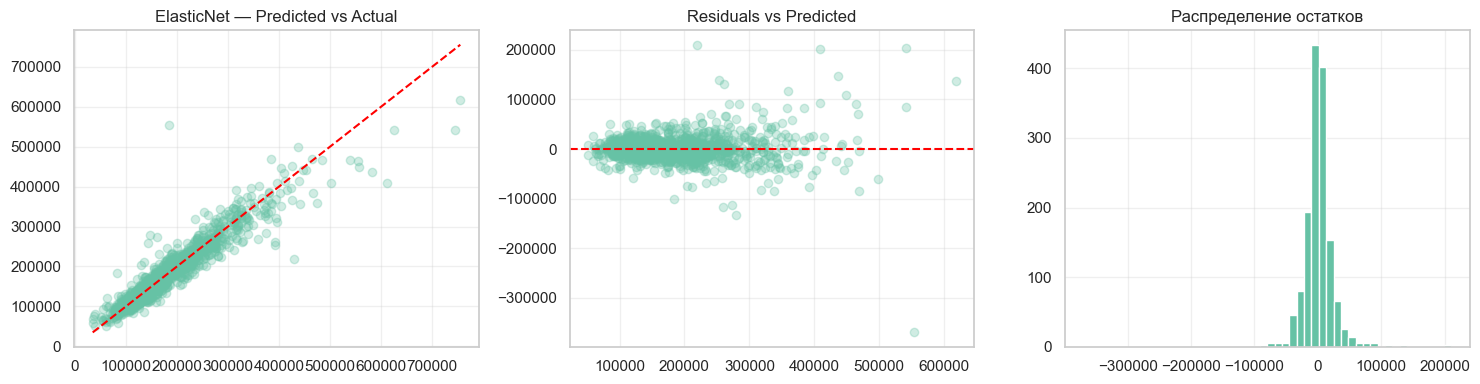

In [74]:
elasticnet_best_pararms = study_elasticnet.best_params
elasticnet = ElasticNet(**elasticnet_best_pararms)
model, pipe, y_pred, residuals = model_train(model=elasticnet,
                                              X_train=X_train,
                                              y_train=y_train,
                                              notes="elasticnet after optuna",
                                              feature_engineering="v9 = TE + Base + Bool + Multiply + NoLinear Quality",
                                              preprocessing="fillna + clip",
                                              cv_folds=10
                                             )
    
visualise_mistakes(model, y_train, y_pred, residuals)

## LGBM optuna tunning

In [75]:
study_lgbm = run_optuna(lgb.LGBMRegressor, X_train, y_train, n_trials=50)

[I 2026-06-13 05:59:04,974] A new study created in memory with name: no-name-efe01e09-7ff6-4ba9-bf49-acd9550f1003


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-13 05:59:12,609] Trial 0 finished with value: 0.12560116718496064 and parameters: {'n_estimators': 1670, 'max_depth': 7, 'learning_rate': 0.012479748045612903, 'num_leaves': 25, 'subsample': 0.8999649853553413, 'colsample_bytree': 0.7194470926084002, 'min_child_samples': 31, 'reg_alpha': 7.945254932241942e-08, 'reg_lambda': 4.938522185639014e-05}. Best is trial 0 with value: 0.12560116718496064.
[I 2026-06-13 05:59:20,636] Trial 1 finished with value: 0.12526188559175824 and parameters: {'n_estimators': 1740, 'max_depth': 8, 'learning_rate': 0.017645481795520515, 'num_leaves': 106, 'subsample': 0.9617837067580226, 'colsample_bytree': 0.7298034995674709, 'min_child_samples': 34, 'reg_alpha': 0.013998923851660194, 'reg_lambda': 1.9997065559072938e-08}. Best is trial 1 with value: 0.12526188559175824.
[I 2026-06-13 05:59:29,301] Trial 2 finished with value: 0.12513044304691293 and parameters: {'n_estimators': 1745, 'max_depth': 4, 'learning_rate': 0.007841973056436947, 'num_lea

In [27]:
lgbm_best_params = {'n_estimators': 1565, 'max_depth': 4, 'learning_rate': 0.023724005575217318, 'num_leaves': 92, 'subsample': 0.8697180467239349, 'colsample_bytree': 0.6262582333939515, 'min_child_samples': 5, 'reg_alpha': 5.654693060700148e-07, 'reg_lambda': 4.866932267657026e-05}

In [76]:
lgbm_best_params = study_lgbm.best_params
lgbm_best_params

{'n_estimators': 1565,
 'max_depth': 4,
 'learning_rate': 0.023724005575217318,
 'num_leaves': 92,
 'subsample': 0.8697180467239349,
 'colsample_bytree': 0.6262582333939515,
 'min_child_samples': 5,
 'reg_alpha': 5.654693060700148e-07,
 'reg_lambda': 4.866932267657026e-05}

LGBMRegressor RMSE: 0.1224


2026/06/13 06:04:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 06:04:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/13 06:05:02 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmp7_n37ejy\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


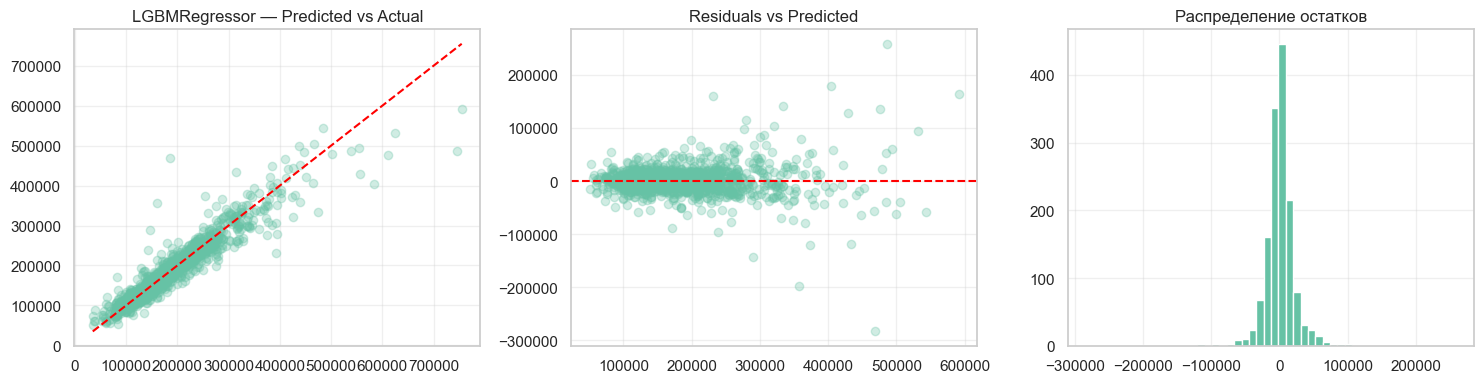

In [77]:
lightgbm = lgb.LGBMRegressor(**lgbm_best_params)
model, pipe, y_pred, residuals = modeling(model=lightgbm,
                                              X_train=X_train,
                                              y_train=y_train,
                                              notes="lgbm after optuna",
                                              feature_engineering="v9 = TE + Base + Bool + Multiply + NoLinear Quality",
                                              preprocessing="fillna + clip",
                                              cv_folds=10
                                             )
    
visualise_mistakes(model, y_train, y_pred, residuals)

## XGBoost

In [88]:
study_xgb = run_optuna(XGBRegressor, X_train, y_train, n_trials=50)

[I 2026-06-13 06:07:18,379] A new study created in memory with name: no-name-2587c7d7-938b-4230-af32-ba348b4f462d


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-13 06:07:26,035] Trial 0 finished with value: 0.12430876877910364 and parameters: {'n_estimators': 374, 'max_depth': 6, 'learning_rate': 0.06975567241605649, 'subsample': 0.6994937087660884, 'colsample_bytree': 0.9615048860280586, 'colsample_bylevel': 0.7500356867747312, 'min_child_weight': 2, 'reg_alpha': 0.00014513620140091802, 'reg_lambda': 0.6377744890618495, 'gamma': 0.07003246229227716}. Best is trial 0 with value: 0.12430876877910364.
[I 2026-06-13 06:08:10,654] Trial 1 finished with value: 0.12168399623770913 and parameters: {'n_estimators': 1640, 'max_depth': 7, 'learning_rate': 0.005826724646388195, 'subsample': 0.684376149958554, 'colsample_bytree': 0.6758198186630286, 'colsample_bylevel': 0.8211730289644456, 'min_child_weight': 8, 'reg_alpha': 0.47975242022344716, 'reg_lambda': 4.1815962029742903e-08, 'gamma': 0.003223388975555492}. Best is trial 1 with value: 0.12168399623770913.
[I 2026-06-13 06:08:38,807] Trial 2 finished with value: 0.12073193924080397 and pa

In [26]:
xgb_best_params = {'n_estimators': 1375, 'max_depth': 4, 'learning_rate': 0.021813765253869643, 'subsample': 0.6277374930492325, 'colsample_bytree': 0.7663555506048277, 'colsample_bylevel': 0.8348242927865861, 'min_child_weight': 1, 'reg_alpha': 1.6906431995031806e-07, 'reg_lambda': 5.875689821307955e-08, 'gamma': 1.0544594864170722e-07}

[autoreload of modeling failed: Traceback (most recent call last):
  File "C:\Anaconda\Lib\site-packages\IPython\extensions\autoreload.py", line 322, in check
    elif self.deduper_reloader.maybe_reload_module(m):
         ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^
  File "C:\Anaconda\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 545, in maybe_reload_module
    new_source_code = f.read()
  File "C:\Anaconda\Lib\encodings\cp1251.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x98 in position 4943: character maps to <undefined>
]


XGBRegressor RMSE: 0.1206


2026/06/13 06:28:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 06:28:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/13 06:29:02 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmp0dl7bes1\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


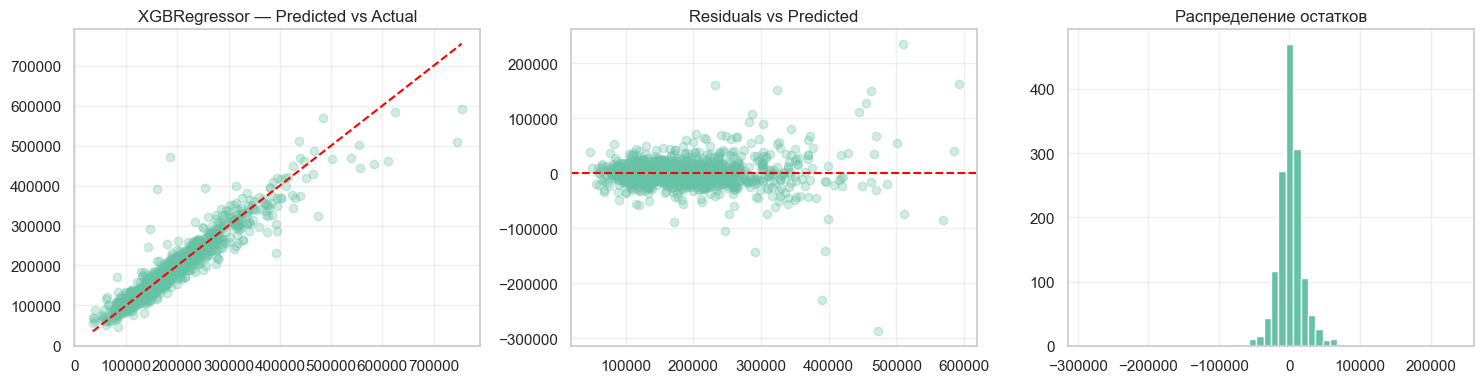

In [89]:
xgb_best_params = study_xgb.best_params
xgboost = XGBRegressor(**xgb_best_params)
model, pipe, y_pred, residuals = model_train(model=xgboost,
                                              X_train=X_train,
                                              y_train=y_train,
                                              notes="xgbr after optuna",
                                              feature_engineering="v9 = TE + Base + Bool + Multiply + NoLinear Quality",
                                              preprocessing="fillna + clip",
                                              cv_folds=10
                                             )
    
visualise_mistakes(model, y_train, y_pred, residuals)

## Catboost optuna tunning

In [93]:
study_catboost = run_optuna(CatBoostRegressor, X_train, y_train, n_trials=20)

[I 2026-06-13 06:30:42,667] A new study created in memory with name: no-name-49d8b241-7b96-4dbb-aa14-bb1c70085ee6


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-06-13 06:30:59,583] Trial 0 finished with value: 0.11985632003041666 and parameters: {'iterations': 1926, 'depth': 3, 'learning_rate': 0.015019705314189702, 'l2_leaf_reg': 5.656756138514486e-07, 'subsample': 0.730418315609725}. Best is trial 0 with value: 0.11985632003041666.
[I 2026-06-13 06:31:43,742] Trial 1 finished with value: 0.11970875833944405 and parameters: {'iterations': 584, 'depth': 8, 'learning_rate': 0.05976682054288877, 'l2_leaf_reg': 4.887402398470019e-05, 'subsample': 0.7390444426415348}. Best is trial 1 with value: 0.11970875833944405.
[I 2026-06-13 06:32:39,541] Trial 2 finished with value: 0.11871744322703803 and parameters: {'iterations': 1727, 'depth': 8, 'learning_rate': 0.05636021204801869, 'l2_leaf_reg': 2.0282881351001165e-08, 'subsample': 0.988906497109605}. Best is trial 2 with value: 0.11871744322703803.
[I 2026-06-13 06:33:21,341] Trial 3 finished with value: 0.11857490861895874 and parameters: {'iterations': 546, 'depth': 7, 'learning_rate': 0.01

In [28]:
catboost_best_params = {'iterations': 1922, 'depth': 6, 'learning_rate': 0.009252110567557769, 'l2_leaf_reg': 9.610808243725543e-06, 'subsample': 0.8297784987693126}

0:	learn: 0.3916209	total: 4.37ms	remaining: 8.39s
1:	learn: 0.3888734	total: 8.47ms	remaining: 8.13s
2:	learn: 0.3862914	total: 12.5ms	remaining: 7.99s
3:	learn: 0.3836271	total: 16.3ms	remaining: 7.8s
4:	learn: 0.3810008	total: 20.1ms	remaining: 7.69s
5:	learn: 0.3782804	total: 24ms	remaining: 7.66s
6:	learn: 0.3757709	total: 27.6ms	remaining: 7.56s
7:	learn: 0.3732257	total: 31.5ms	remaining: 7.55s
8:	learn: 0.3706882	total: 35.3ms	remaining: 7.51s
9:	learn: 0.3682776	total: 39.2ms	remaining: 7.5s
10:	learn: 0.3658837	total: 43.2ms	remaining: 7.5s
11:	learn: 0.3635575	total: 46.9ms	remaining: 7.47s
12:	learn: 0.3612885	total: 50.8ms	remaining: 7.46s
13:	learn: 0.3589468	total: 54.9ms	remaining: 7.49s
14:	learn: 0.3566262	total: 58.6ms	remaining: 7.45s
15:	learn: 0.3542953	total: 62.5ms	remaining: 7.45s
16:	learn: 0.3520052	total: 66.2ms	remaining: 7.42s
17:	learn: 0.3497007	total: 70.1ms	remaining: 7.41s
18:	learn: 0.3474831	total: 74ms	remaining: 7.41s
19:	learn: 0.3452256	total: 7

KeyboardInterrupt: 

Exception ignored in: '_catboost._WriteLog'
Traceback (most recent call last):
  File "C:\Anaconda\Lib\site-packages\IPython\core\interactiveshell.py", line 3043, in write
    def write(data, *args, **kwargs):
KeyboardInterrupt: 


824:	learn: 0.0785184	total: 3.97s	remaining: 5.28s
825:	learn: 0.0784517	total: 3.97s	remaining: 5.27s
826:	learn: 0.0784033	total: 3.98s	remaining: 5.27s
827:	learn: 0.0783583	total: 3.98s	remaining: 5.26s
828:	learn: 0.0783008	total: 3.99s	remaining: 5.26s
829:	learn: 0.0782323	total: 3.99s	remaining: 5.25s
830:	learn: 0.0782069	total: 4s	remaining: 5.25s
831:	learn: 0.0781525	total: 4s	remaining: 5.24s
832:	learn: 0.0780874	total: 4.01s	remaining: 5.24s
833:	learn: 0.0780253	total: 4.01s	remaining: 5.23s
834:	learn: 0.0779806	total: 4.02s	remaining: 5.23s
835:	learn: 0.0779450	total: 4.02s	remaining: 5.22s
836:	learn: 0.0778769	total: 4.03s	remaining: 5.22s
837:	learn: 0.0778016	total: 4.03s	remaining: 5.21s
838:	learn: 0.0777686	total: 4.04s	remaining: 5.21s
839:	learn: 0.0777220	total: 4.04s	remaining: 5.21s
840:	learn: 0.0776736	total: 4.05s	remaining: 5.2s
841:	learn: 0.0776460	total: 4.05s	remaining: 5.2s
842:	learn: 0.0776054	total: 4.06s	remaining: 5.19s
843:	learn: 0.077547

2026/06/13 06:50:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


1889:	learn: 0.0472062	total: 10.2s	remaining: 172ms
1890:	learn: 0.0471873	total: 10.2s	remaining: 167ms
1891:	learn: 0.0471590	total: 10.2s	remaining: 161ms
1892:	learn: 0.0471434	total: 10.2s	remaining: 156ms
1893:	learn: 0.0471241	total: 10.2s	remaining: 151ms
1894:	learn: 0.0470970	total: 10.2s	remaining: 145ms
1895:	learn: 0.0470731	total: 10.2s	remaining: 140ms
1896:	learn: 0.0470599	total: 10.2s	remaining: 134ms
1897:	learn: 0.0470432	total: 10.2s	remaining: 129ms
1898:	learn: 0.0470253	total: 10.2s	remaining: 124ms
1899:	learn: 0.0470014	total: 10.2s	remaining: 118ms
1900:	learn: 0.0469855	total: 10.2s	remaining: 113ms
1901:	learn: 0.0469760	total: 10.2s	remaining: 108ms
1902:	learn: 0.0469437	total: 10.2s	remaining: 102ms
1903:	learn: 0.0469172	total: 10.2s	remaining: 96.8ms
1904:	learn: 0.0469005	total: 10.2s	remaining: 91.4ms
1905:	learn: 0.0468834	total: 10.2s	remaining: 86ms
1906:	learn: 0.0468508	total: 10.2s	remaining: 80.6ms
1907:	learn: 0.0468231	total: 10.3s	remainin

2026/06/13 06:50:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/13 06:50:43 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmp2up3woy6\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


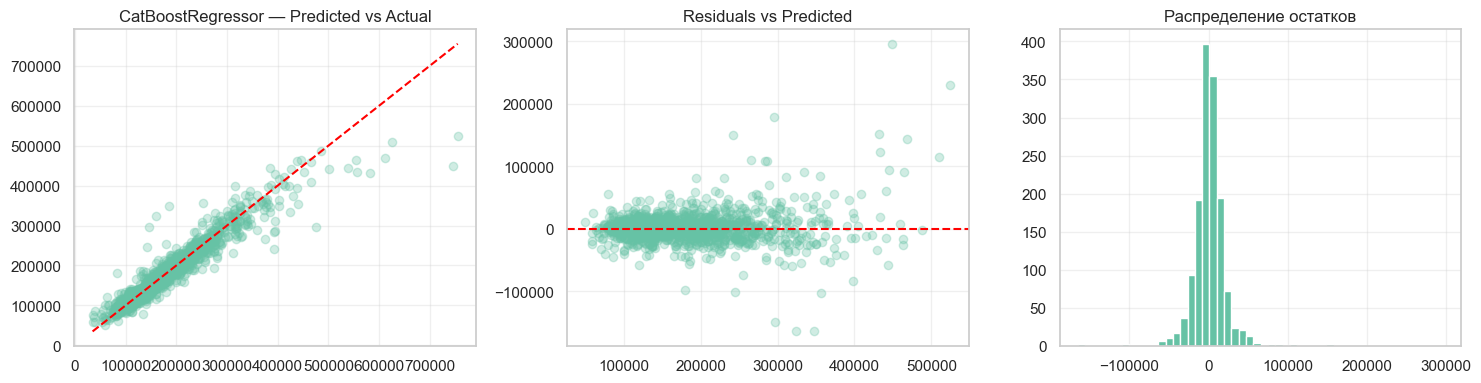

In [95]:
catboost_best_params = study_catboost.best_params
catboost = CatBoostRegressor(**catboost_best_params, verb)
model, pipe, y_pred, residuals = model_train(model=catboost,
                                              X_train=X_train,
                                              y_train=y_train,
                                              notes="catboost after optuna",
                                              feature_engineering="v9 = TE + Base + Bool + Multiply + NoLinear Quality",
                                              preprocessing="fillna + clip",
                                              cv_folds=10
                                             )
    
visualise_mistakes(model, y_train, y_pred, residuals)

## L2 Stacking

In [29]:
l1_models = [
    ('catboost', CatBoostRegressor(**catboost_best_params, verbose=0), catboost_best_params),
    ('lgbm',     lgb.LGBMRegressor(**lgbm_best_params, verbose=-1),         lgbm_best_params),
    ('xgb',      XGBRegressor(**xgb_best_params, verbosity=0),           xgb_best_params),
    ('ridge',    Ridge(**ridge_best_pararms),                ridge_best_pararms),
    ('elasticnet', ElasticNet(**elasticnet_best_pararms),         elasticnet_best_pararms),
]

y_test_pred, meta_model, oof_preds, test_preds = run_stacking(
    l1_models=l1_models,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    cv=10,
    tune_meta=True,
    n_trials=50
)

# сабмит
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': y_test_pred
})
submission.to_csv(f'{OUTPUT_DIR}/submission.csv', index=False)

=== L1: обучение базовых моделей ===
L1 catboost OOF RMSLE: 0.1178


2026/06/13 16:53:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 16:53:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/13 16:53:55 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmpe1r3mp4v\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


L1 lgbm OOF RMSLE: 0.1228


2026/06/13 16:54:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 16:54:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/13 16:54:14 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmpvlst66ml\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


L1 xgb OOF RMSLE: 0.1207


...

[I 2026-06-13 16:54:56,354] Trial 0 finished with value: 0.11683356368143137 and parameters: {'alpha': 0.3004891406893272}. Best is trial 0 with value: 0.11683356368143137.
[I 2026-06-13 16:54:56,370] Trial 1 finished with value: 0.11684600171023111 and parameters: {'alpha': 0.02048500485546318}. Best is trial 0 with value: 0.11683356368143137.
[I 2026-06-13 16:54:56,387] Trial 2 finished with value: 0.11731114416647151 and parameters: {'alpha': 24.228878523279796}. Best is trial 0 with value: 0.11683356368143137.
[I 2026-06-13 16:54:56,404] Trial 3 finished with value: 0.11763345776083245 and parameters: {'alpha': 32.90833323702464}. Best is trial 0 with value: 0.11683356368143137.
[I 2026-06-13 16:54:56,421] Trial 4 finished with value: 0.11684736333510504 and parameters: {'alpha': 0.7097516391359773}. Best is trial 0 with value: 0.11683356368143137.
[I 2026-06-13 16:54:56,438] Trial 5 finished with value: 0.11684893049810846 and parameters: {'alpha': 0.018721470213058596}. Best is t

2026/06/13 16:54:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 16:54:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best meta RMSLE: 0.1168
Best meta params: {'alpha': 0.09024482449672896}
=== L2: финальное обучение мета-модели ===
L2 meta OOF RMSE: 0.1168


2026/06/13 16:55:01 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmpgw4wofds\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 



=== Итог: Stacking RMSE: 0.1168 ===


In [33]:
l1_models = [
    ('catboost', CatBoostRegressor(**catboost_best_params, verbose=0), catboost_best_params),
    # ('lgbm',     lgb.LGBMRegressor(**lgbm_best_params, verbose=-1),         lgbm_best_params),
    ('xgb',      XGBRegressor(**xgb_best_params, verbosity=0),           xgb_best_params),
    ('ridge',    Ridge(**ridge_best_pararms),                ridge_best_pararms),
    # ('elasticnet', ElasticNet(**elasticnet_best_pararms),         elasticnet_best_pararms),
]

y_test_pred, meta_model, oof_preds, test_preds = run_stacking(
    l1_models=l1_models,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    cv=10,
    tune_meta=True,
    n_trials=50
)

# сабмит
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': y_test_pred
})
submission.to_csv(f'{OUTPUT_DIR}/submission.csv', index=False)

=== L1: обучение базовых моделей ===
L1 catboost OOF RMSLE: 0.1183


2026/06/13 17:06:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 17:06:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/13 17:06:10 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmp1op0nav7\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


L1 xgb OOF RMSLE: 0.1197


2026/06/13 17:06:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 17:06:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/13 17:06:37 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmpevyun0va\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 
2026/06/13 17:06:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


L1 ridge OOF RMSLE: 0.1251


...

[I 2026-06-13 17:06:42,778] Trial 0 finished with value: 0.1165482683197013 and parameters: {'alpha': 0.00048655642399296744}. Best is trial 0 with value: 0.1165482683197013.
[I 2026-06-13 17:06:42,792] Trial 1 finished with value: 0.1173421736437698 and parameters: {'alpha': 25.857053588172132}. Best is trial 0 with value: 0.1165482683197013.
[I 2026-06-13 17:06:42,809] Trial 2 finished with value: 0.11654457902588007 and parameters: {'alpha': 0.009679643585745802}. Best is trial 2 with value: 0.11654457902588007.
[I 2026-06-13 17:06:42,824] Trial 3 finished with value: 0.11629639965771535 and parameters: {'alpha': 1.80280740808122}. Best is trial 3 with value: 0.11629639965771535.
[I 2026-06-13 17:06:42,839] Trial 4 finished with value: 0.11653028251406482 and parameters: {'alpha': 0.04714448763920614}. Best is trial 3 with value: 0.11629639965771535.
[I 2026-06-13 17:06:42,855] Trial 5 finished with value: 0.11654735479651489 and parameters: {'alpha': 0.002745545004864286}. Best is 

2026/06/13 17:06:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== L2: финальное обучение мета-модели ===
L2 meta OOF RMSE: 0.1162


2026/06/13 17:06:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/13 17:06:47 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmpaohjycua\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 



=== Итог: Stacking RMSE: 0.1162 ===


## Analise

In [32]:
# 5 models

In [31]:
stacking_weights = pd.DataFrame({
    'model': l1_models,
    'coef': meta_model.coef_,
})
stacking_weights

,model,coef
0,"(catboost, CatBoostRegressor(depth=6, iteratio...",0.559806
1,"(lgbm, LGBMRegressor(colsample_bytree=0.626258...",0.022149
2,"(xgb, XGBRegressor(base_score=None, booster=No...",0.204394
3,"(ridge, Ridge(alpha=0.6531771025930252), {'alp...",0.626693
4,"(elasticnet, ElasticNet(alpha=0.00023207027009...",-0.400839


- Ridge (0.63) и CatBoost (0.56) — основные предсказатели, несут главный сигнал
- XGBoost (0.20) — вносит дополнительный вклад
- LightGBM (0.02) — почти не влияет, его информация уже покрыта другими моделями
- ElasticNet (-0.40) — мета-модель использует его как корректирующий сигнал в обратную сторону

Попробую стекинг с 3 моделями Ridge, Catboost, XGB

In [34]:
stacking_weights = pd.DataFrame({
    'model': l1_models,
    'coef': meta_model.coef_,
})
stacking_weights

,model,coef
0,"(catboost, CatBoostRegressor(depth=6, iteratio...",0.344889
1,"(xgb, XGBRegressor(base_score=None, booster=No...",0.344185
2,"(ridge, Ridge(alpha=0.6531771025930252), {'alp...",0.314228


Модели вносят равноценный вклад однако точность не улучшилась как на валидации так и на submission 

## Features

In [37]:
catboost = CatBoostRegressor(**catboost_best_params, verbose=0)

In [ ]:
model, pipe, y_pred, residuals = model_train(model=catboost,
                                              X_train=X_train,
                                              y_train=y_train,
                                              notes="catboost after optuna",
                                              feature_engineering="v9 = TE + Base + Bool + Multiply + NoLinear Quality",
                                              preprocessing="fillna + clip",
                                              cv_folds=10
                                             )

In [42]:
feature_names = pipe.named_steps['encoder_scaler'].get_feature_names_out()
feature_names = [name.split('__')[1] for name in feature_names]

importances = model.get_feature_importance()

fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(fi.head(40))

                 feature  importance
113       Quality*Square   12.509235
115          QualityArea    7.386747
0           Neighborhood    5.258000
114  QualityMulty*Square    3.509145
80          OverallScore    3.494209
87               TotalSF    3.254586
91       TotalLivingArea    3.080993
84      TotalHouseSquare    3.070895
112    TotalQualityMulti    2.537359
86             TotalBath    2.259776
118             QualBsmt    2.167806
88        OverallQual_sq    2.084347
119           QualGarage    2.015477
2               MSZoning    2.009054
11         SaleCondition    1.986995
46               LotArea    1.835404
48           OverallCond    1.744079
47           OverallQual    1.611263
117     OverallQual_cube    1.596981
101      TotalQualitySum    1.550644
69            GarageCars    1.415877
52            BsmtFinSF1    1.383321
81              HouseAge    1.314755
54             BsmtUnfSF    1.241101
50          YearRemodAdd    1.233983
59             GrLivArea    1.216431
1

Если выделять блоки, наибольшее влияние оказывают манипуляции с Quality и Площадью (разными ее частями)